# MoE denoiser — quick demo

Companion to the **adaptive autoencoder** notebook. Same 6 s mixed-noise clip: an RF classifier picks one of **six expert denoisers** per frame (best setup: **smoothed RF routing**).

Run all cells (~5–15 s). Uses precomputed audio; routing plots load from cache or recompute from the demo router only (no full retrain).

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display
from sklearn.metrics import confusion_matrix

%matplotlib inline

REPO = Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from moe_baseline.config import CHANNEL_NAMES, NUM_FAMILIES, TARGET_SR
from moe_baseline.demo_routing import load_or_compute_routing

SR = TARGET_SR
OUT = REPO / "outputs" / "moe_presentation_demo"
CKPT = REPO / "checkpoints" / "moe_speech_demo"
WAV = OUT / "wav"
VOTE_WINDOW = 5

paths = {
    "clean": WAV / "01_original.wav",
    "noisy": WAV / "02_mixed_noisy.wav",
    "moe": WAV / "05_moe_classifier_smoothed.wav",
}
missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        f"Missing {missing}. Run: python scripts/run_moe_presentation_demo.py"
    )

def load_wav(p):
    x, _ = sf.read(str(p), dtype="float32")
    return x if x.ndim == 1 else x.mean(axis=1)

clean = load_wav(paths["clean"])
noisy = load_wav(paths["noisy"])
moe = load_wav(paths["moe"])
n = min(len(clean), len(noisy), len(moe))
clean, noisy, moe = clean[:n], noisy[:n], moe[:n]
print(f"Loaded {n/SR:.1f}s audio from {OUT}")

Loaded 6.0s audio from /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/outputs/moe_presentation_demo


In [19]:
bundle = load_or_compute_routing(OUT, CKPT, clean, vote_window=VOTE_WINDOW)
true = bundle["true_labels"]
pred = bundle["pred_smooth"]  # best MoE routing
n_frames = len(true)
acc = float((true == pred).mean())
print(f"Frames: {n_frames} | Routing accuracy (smoothed RF): {acc:.1%}")

Frames: 187 | Routing accuracy (smoothed RF): 65.2%


In [20]:
metrics_path = OUT / "demo_metrics.csv"
if metrics_path.exists():
    m = pd.read_csv(metrics_path).set_index("metric")["value"]

    def num(key, default=float("nan")):
        try:
            return float(m.get(key, default))
        except (TypeError, ValueError):
            return default

    nr = num("nr_db_demo_smooth")
    if np.isnan(nr):
        nr = num("nr_db_classifier")
    print(f"Noise reduction (MoE smoothed): {nr:.2f} dB")

Noise reduction (MoE smoothed): 1.78 dB


## Routing: true family vs MoE choice

Audio is split into **frames** (~32 ms each; 512 samples at 16 kHz). For every frame the system must pick one of **six noise experts**.

**RF** = **Random Forest** classifier trained on **log-FFT spectral features** of each noisy frame. It outputs one noise-family label per frame (the “which expert?” decision).

**Smoothed (w = 5)** = after the RF labels each frame, we **stabilize** the route with a short **majority vote**: for frame *i*, look at the RF choices in a window of **5 consecutive frames** (2 before, current, 2 after) and pick the **most common** label. That dampens single-frame mistakes and stops the expert from **flickering** at segment boundaries—similar in spirit to the adaptive notebook’s temporal smoothing, but here applied to **discrete routing** rather than latent channels.

The denoised audio and plots use this **smoothed** route (our best MoE setting), not the raw per-frame RF labels.

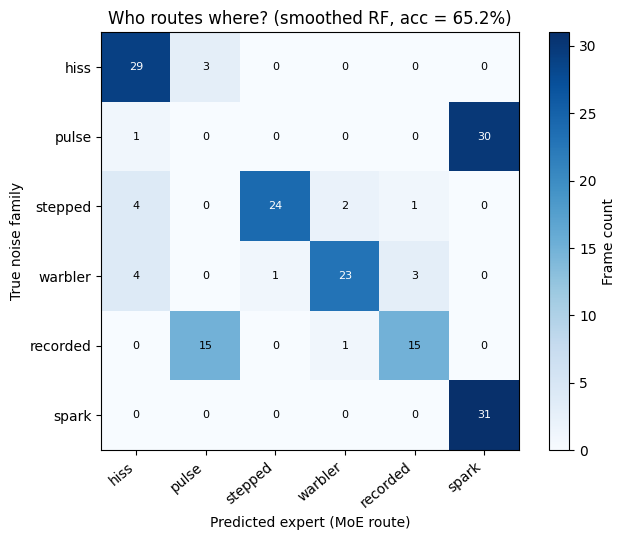

In [27]:
cm = confusion_matrix(true, pred, labels=list(range(NUM_FAMILIES)))

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_FAMILIES))
ax.set_yticks(range(NUM_FAMILIES))
ax.set_xticklabels(CHANNEL_NAMES, rotation=40, ha="right")
ax.set_yticklabels(CHANNEL_NAMES)
ax.set_xlabel("Predicted expert (MoE route)")
ax.set_ylabel("True noise family")
ax.set_title(f"Who routes where? (smoothed RF, acc = {acc:.1%})")
for i in range(NUM_FAMILIES):
    for j in range(NUM_FAMILIES):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, label="Frame count")
plt.tight_layout()
plt.show()

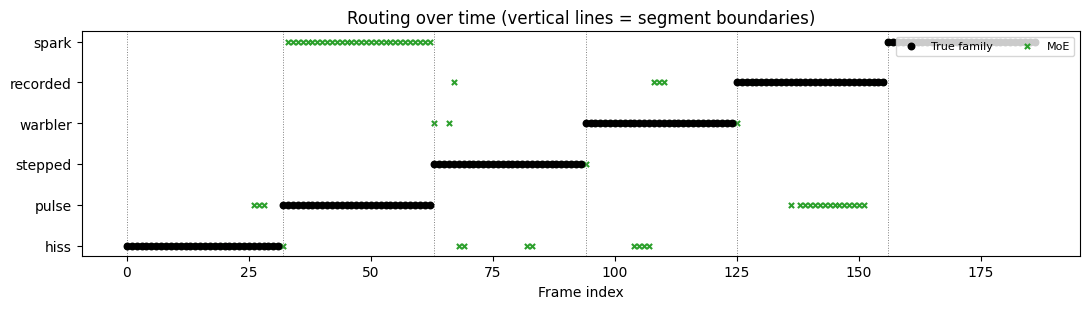

In [33]:
fig, ax = plt.subplots(figsize=(11, 3.2))
x = np.arange(n_frames)
ax.scatter(x, true, s=22, c="black", label="True family", zorder=3)
ax.scatter(x, pred, s=14, c="C2", marker="x", label=f"MoE")
for s in bundle["segment_starts"]:
    if s >= 0:
        ax.axvline(int(s), color="gray", ls=":", lw=0.7)
ax.set_yticks(range(NUM_FAMILIES))
ax.set_yticklabels(CHANNEL_NAMES)
ax.set_xlabel("Frame index")
ax.set_title("Routing over time (vertical lines = segment boundaries)")
ax.legend(loc="upper right", ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

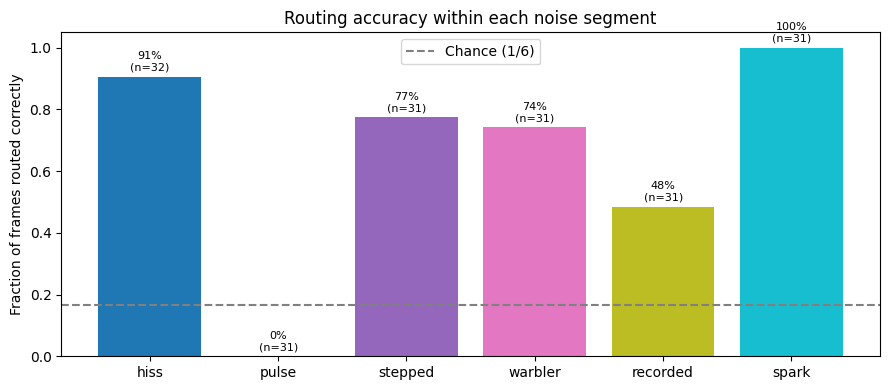

In [34]:
# Per-segment: when noise is family k, how often does the router pick k?
seg_acc, seg_n = [], []
for k, name in enumerate(CHANNEL_NAMES):
    mask = true == k
    seg_n.append(int(mask.sum()))
    seg_acc.append(float((pred[mask] == k).mean()) if mask.any() else 0.0)

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 1, NUM_FAMILIES))
bars = ax.bar(CHANNEL_NAMES, seg_acc, color=colors)
ax.axhline(1 / NUM_FAMILIES, color="gray", ls="--", label="Chance (1/6)")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fraction of frames routed correctly")
ax.set_title("Routing accuracy within each noise segment")
for b, a, cnt in zip(bars, seg_acc, seg_n):
    ax.text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.0%}\n(n={cnt})", ha="center", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

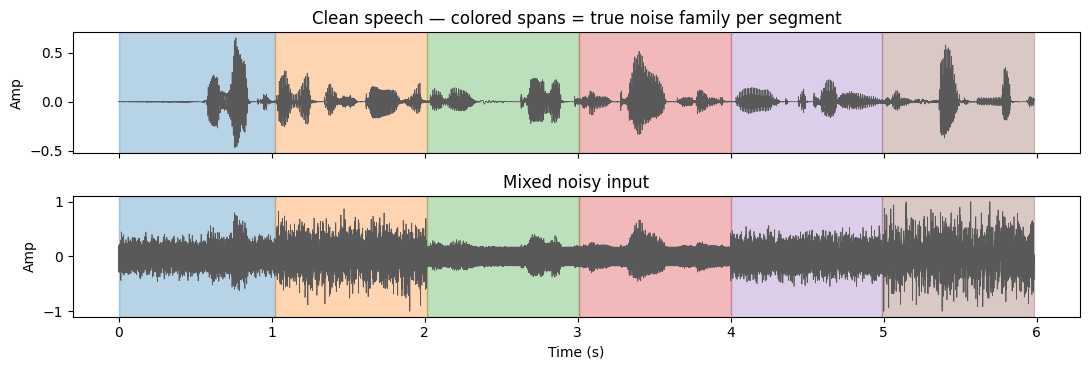

In [35]:
hop = 512
seconds_show = min(6.0, n / SR)
n_show = int(seconds_show * SR)
t = np.arange(n_show) / SR

fig, axes = plt.subplots(2, 1, figsize=(11, 3.8), sharex=True)
axes[0].plot(t, clean[:n_show], color="0.35", lw=0.55)
axes[1].plot(t, noisy[:n_show], color="0.35", lw=0.55)
for fam_id, name in enumerate(CHANNEL_NAMES):
    s = int(bundle["segment_starts"][fam_id])
    if s < 0:
        continue
    t0 = s * hop / SR
    if fam_id + 1 < NUM_FAMILIES and int(bundle["segment_starts"][fam_id + 1]) >= 0:
        t1 = int(bundle["segment_starts"][fam_id + 1]) * hop / SR
    else:
        t1 = seconds_show
    for ax in axes:
        ax.axvspan(t0, t1, alpha=0.32, color=plt.cm.tab10(fam_id))
axes[0].set_title("Clean speech — colored spans = true noise family per segment")
axes[1].set_title("Mixed noisy input")
axes[1].set_xlabel("Time (s)")
for ax in axes:
    ax.set_ylabel("Amp")
plt.tight_layout()
plt.show()

## Denoising result (listen + waveforms)

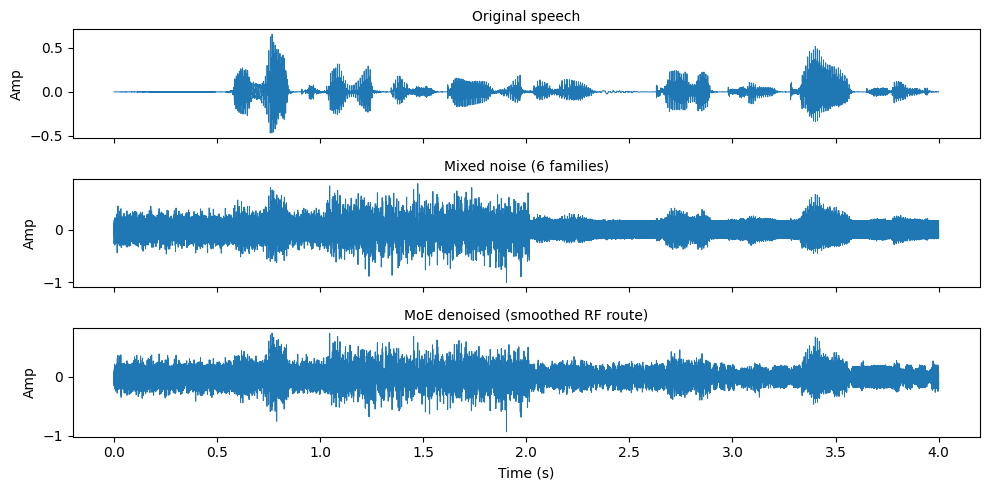

In [36]:
def plot_moe_demo(original, noisy_in, moe_out, sr=16000, seconds=4.0):
    n_plot = int(min(seconds * sr, len(original)))
    t = np.arange(n_plot) / sr
    fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
    for ax, y, title in zip(
        axes,
        [original[:n_plot], noisy_in[:n_plot], moe_out[:n_plot]],
        ["Original speech", "Mixed noise (6 families)", "MoE denoised (smoothed RF route)"],
    ):
        ax.plot(t, y, lw=0.7)
        ax.set_ylabel("Amp")
        ax.set_title(title, fontsize=10)
    axes[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

plot_moe_demo(clean, noisy, moe, SR)

In [37]:
for label, sig in [("Original", clean), ("Mixed noisy", noisy), ("MoE denoised", moe)]:
    print(label)
    display(Audio(sig, rate=SR))

Original


Mixed noisy


MoE denoised
